In [1]:
import numpy as np
import pandas as pd

# !pip install ucimlrepo
# !pip install pytorch-tabnet
# !pip install pytorch-tabular

In [2]:
import warnings

warnings.filterwarnings("ignore")

For this project, I chose a Tabular dataset which fitted the criteria of a **Classification** task:

Covertype
---

 - Source: https://archive.ics.uci.edu/dataset/31/covertype
 - Classifies pixels from forest imagery into 7 types: <br/>
        - spruce/fir            <br/>
        - Lodgepole Pine        <br/>
        - Ponderosa Pine        <br/>
        - Cottonwood/Willow     <br/>
        - Aspen                 <br/>
        - Douglas-fir           <br/>
        - Krummholz             <br/>

  - Has 54 original features. Features like: soil type, elevation, vertical distance to hidrology.

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets['Cover_Type']

# variable information
print(covertype.variables)

                                  name     role     type demographic  \
0                            Elevation  Feature  Integer        None   
1                               Aspect  Feature  Integer        None   
2                                Slope  Feature  Integer        None   
3     Horizontal_Distance_To_Hydrology  Feature  Integer        None   
4       Vertical_Distance_To_Hydrology  Feature  Integer        None   
5      Horizontal_Distance_To_Roadways  Feature  Integer        None   
6                        Hillshade_9am  Feature  Integer        None   
7                       Hillshade_Noon  Feature  Integer        None   
8                        Hillshade_3pm  Feature  Integer        None   
9   Horizontal_Distance_To_Fire_Points  Feature  Integer        None   
10                    Wilderness_Area1  Feature  Integer        None   
11                          Soil_Type1  Feature  Integer        None   
12                          Soil_Type2  Feature  Integer        

### Feature Engineering

**Elevation to Hydrology Ratio** ===> Trees that are not near rivers/creeks are different than those which are, at same elevation.
<br/>
**Terrain roughness** ===> Slope * Elevation

In [4]:
X["Elevation_to_Hydrology_Ratio"] = (
    X["Elevation"] /
    (X["Horizontal_Distance_To_Hydrology"] + 1)
)
X["Terrain_Roughness"] = (
    X["Elevation"] * X["Slope"]
)

### Feature Engineering

Since Aspect (angle to azimuth) is withing 0-360, I thought that it would help the model to convert these value to [-1, 1], using **sin** and **cos**.

In [5]:
X["Aspect_sin"] = np.sin(np.radians(X["Aspect"]))
X["Aspect_cos"] = np.cos(np.radians(X["Aspect"]))
X.drop(columns=["Aspect"])

,Elevation,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,...,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Elevation_to_Hydrology_Ratio,Terrain_Roughness,Aspect_sin,Aspect_cos
0,2596,3,258,0,510,221,232,148,6279,1,...,0,0,0,0,0,0,10.023166,7788,0.777146,0.629320
1,2590,2,212,-6,390,220,235,151,6225,1,...,0,0,0,0,0,0,12.159624,5180,0.829038,0.559193
2,2804,9,268,65,3180,234,238,135,6121,1,...,0,0,0,0,0,0,10.423792,25236,0.656059,-0.754710
3,2785,18,242,118,3090,238,238,122,6211,1,...,0,0,0,0,0,0,11.460905,50130,0.422618,-0.906308
4,2595,2,153,-1,391,220,234,150,6172,1,...,0,0,0,0,0,0,16.850649,5190,0.707107,0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,20,85,17,108,240,237,118,837,0,...,0,0,0,0,1,0,27.860465,47920,0.453990,-0.891007
581008,2391,19,67,12,95,240,237,119,845,0,...,0,0,0,0,1,0,35.161765,45429,0.469472,-0.882948
581009,2386,17,60,7,90,236,241,130,854,0,...,0,0,0,0,1,0,39.114754,40562,0.358368,-0.933580
581010,2384,15,60,5,90,230,245,143,864,0,...,0,0,0,0,1,0,39.081967,35760,0.173648,-0.984808


In [6]:
print(X.shape)
print(y.shape)

(581012, 58)
(581012,)


#### Number of classes:

In [7]:
len(set(y))

7

#### Criteria for metric selection on classification tasks is how balanced the dataset is. In our case, the difference in the number of instances between classes <br/> is major, thus, metrics like 'Macro-Averaged F1-Score' and 'Multi-class ROC-AUC' may be advantageous for showing poor performance for minority classes.

#### For better coverage, 'Cohen's Kappa' and 'Balanced accuracy' are also selected.

In [8]:
for _type in range(1, len(set(y))):
    print(sum(n == _type for n in y))

211840
283301
35754
2747
9493
17367


In [9]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score, balanced_accuracy_score, cohen_kappa_score

def evaluation(y_val, y_pred, y_proba):

    print(classification_report(y_val, y_pred))

    return {
        'macro_f1_score': f1_score(y_val, y_pred, average='macro'),
        'roc_auc_score': roc_auc_score(y_val, y_proba, multi_class='ovr', average='macro'),
        'balanced_accuracy_score': balanced_accuracy_score(y_val, y_pred),
        'cohen_kappa_score': cohen_kappa_score(y_val, y_pred),
    }

#### Train-test split section

Added stratification, due to high imbalance in class sizes.
Added also validation set, as the F-T Transformer expects a validation split to rationalize on during training (for convergence).

In [10]:
from sklearn.model_selection import train_test_split

#           train+val         test
# [===========80%==========|===20%===]
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42,
    stratify=y
)

#           train             val
# [==========75%=========|====25%====]
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42,
    stratify=y_train_val
)

# Final result:
#         train         val     test
# [========60%=======|==%20==|==%20==]

### Selection of smaller models
#### --- The selection will be done using Chi2 (Chi-squared statistical test, using SelectKBest applied on the batch of features).

#### In order for chi2-selection to work, X's values must be positive. This can be achieved using MinMaxScaler.

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[0.36868434, 0.14166667, 0.04545455, ..., 0.0380125 , 0.88857298,
        0.8146602 ],
       [0.36568284, 0.15555556, 0.03030303, ..., 0.02528309, 0.91451879,
        0.77959645],
       [0.47273637, 0.38611111, 0.13636364, ..., 0.12317454, 0.82802951,
        0.12264521],
       ...,
       [0.26363182, 0.44166667, 0.25757576, ..., 0.1979793 , 0.67918397,
        0.03320979],
       [0.26263132, 0.47222222, 0.22727273, ..., 0.17454119, 0.58682409,
        0.00759612],
       [0.26213107, 0.45833333, 0.1969697 , ..., 0.15120558, 0.62940952,
        0.01703709]], shape=(581012, 58))

In [12]:
from sklearn.feature_selection import SelectKBest, chi2

chi_selections = []

for k in range(10, 54, 5):
    chi2_selector = SelectKBest(score_func=chi2, k=k)

    X_kbest = chi2_selector.fit_transform(X_scaled, y)

    selected_features = chi2_selector.get_support(indices=True)

    chi_selections.append(selected_features)

chi_selections.append([x for x in range(len(X.columns))])

In [13]:
feature_names = X.columns
smallest_model_feature_names = feature_names[chi_selections[0]]

smallest_model_feature_names

Index(['Wilderness_Area1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4',
       'Soil_Type6', 'Soil_Type10', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Wilderness_Area4'],
      dtype='object')

Function to generate the model

In [14]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

def gen_fttransformer(features):
    data_config = DataConfig(
        target=['Cover_Type'],
        continuous_cols=features,
        categorical_cols=[]
    )

    trainer_config = TrainerConfig(
        batch_size=1024,
        max_epochs=15,
        accelerator="gpu",
        early_stopping="valid_loss",
        early_stopping_patience=3
    )

    optimizer_config = OptimizerConfig()

    mode_config = FTTransformerConfig(
        task='classification',
        num_heads=4,
        num_attn_blocks=2,
        learning_rate=1e-3
    )

    tabular_model = TabularModel(
        data_config=data_config,
        model_config=mode_config,
        optimizer_config=optimizer_config,
        trainer_config=trainer_config,
    )

    return tabular_model


W0531 11:13:03.890000 4712 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


The FT Transformer takes a long time to train. GPU setup was needed.

In [15]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Function to train each model on its specific selection of features (done using chi2 + SelectKBest). Metrics and predictions are stored for later usage.

In [ ]:
y_preds = []
y_probas = []
evaluation_dicts = []

for chi_selection in chi_selections:
  current_features = list(feature_names[chi_selection])
  print("No. features: " + str(len(current_features)))

  X_train_selected = X_train[current_features].copy()
  train_df = X_train_selected
  train_df['Cover_Type'] = y_train

  val_df = X_val[current_features].copy()
  val_df["Cover_Type"] = y_val

  ft_transformer = gen_fttransformer(features=current_features)

  ft_transformer.fit(
      train=train_df,
      validation=val_df
  )

  X_test_selected = X_test[current_features]
  test_df = X_test_selected.copy()
  test_df['Cover_Type'] = y_test

  predictions = ft_transformer.predict(X_test)

  proba_cols = [c for c in predictions.columns if c.endswith('_probability')]
  y_proba = predictions[proba_cols].to_numpy()

  y_pred = predictions['Cover_Type_prediction']

  y_preds.append({ len(current_features) : y_pred })
  y_probas.append({ len(current_features) : y_proba })
  evaluation_dicts.append({ len(current_features) : evaluation(y_test, y_pred, y_proba) })

In [17]:
import pandas as pd

rows = []

for d in evaluation_dicts:
    n_features = next(iter(d))
    metrics = d[n_features]

    rows.append({
        "n_features": n_features,
        **metrics
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("n_features")

results_df

,n_features,macro_f1_score,roc_auc_score,balanced_accuracy_score,cohen_kappa_score
0,10,0.305912,0.809125,0.356561,0.250738
1,15,0.392865,0.847281,0.409120,0.374502
2,20,0.502381,0.931143,0.483063,0.524628
3,25,0.634941,0.954978,0.593630,0.603771
4,30,0.701932,0.972026,0.667515,0.691683
5,35,0.733944,0.977712,0.710159,0.729719
6,40,0.759028,0.980587,0.731041,0.752686
7,45,0.770386,0.981856,0.742170,0.755729
8,50,0.794082,0.984343,0.767629,0.774229
9,58,0.778667,0.983244,0.754172,0.768907


In [18]:
results_df.sort_values(
    "macro_f1_score",
    ascending=False
)

,n_features,macro_f1_score,roc_auc_score,balanced_accuracy_score,cohen_kappa_score
8,50,0.794082,0.984343,0.767629,0.774229
9,58,0.778667,0.983244,0.754172,0.768907
7,45,0.770386,0.981856,0.742170,0.755729
6,40,0.759028,0.980587,0.731041,0.752686
5,35,0.733944,0.977712,0.710159,0.729719
4,30,0.701932,0.972026,0.667515,0.691683
3,25,0.634941,0.954978,0.593630,0.603771
2,20,0.502381,0.931143,0.483063,0.524628
1,15,0.392865,0.847281,0.409120,0.374502
0,10,0.305912,0.809125,0.356561,0.250738


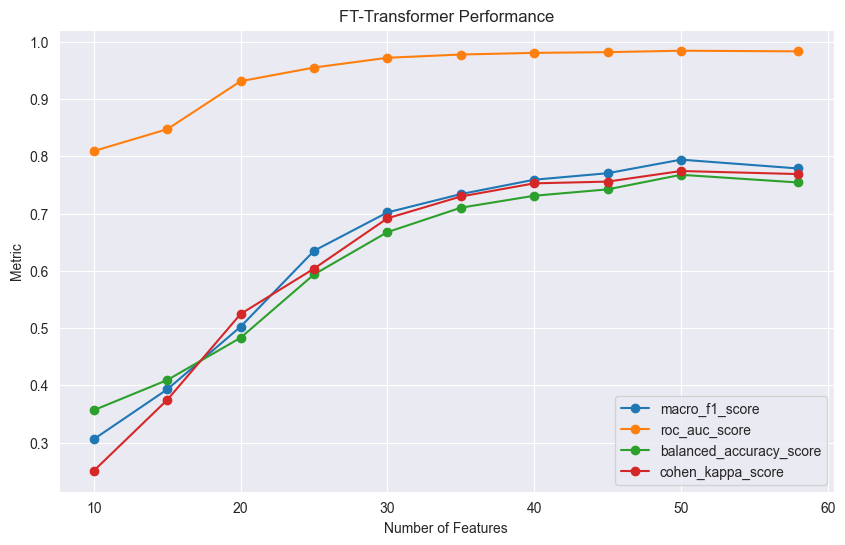

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for col in results_df.columns:
    if col != "n_features":
        plt.plot(
            results_df["n_features"],
            results_df[col],
            marker="o",
            label=col
        )

plt.grid(True)
plt.legend()
plt.xlabel("Number of Features")
plt.ylabel("Metric")
plt.title("FT-Transformer Performance")
plt.show()

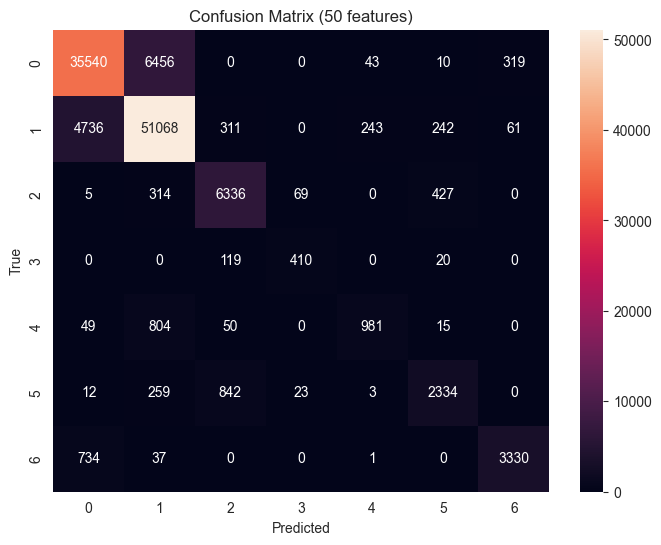

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_n = results_df.loc[
    results_df["macro_f1_score"].idxmax(),
    "n_features"
]

best_pred = None

for d in y_preds:
    if best_n in d:
        best_pred = d[best_n]
        break

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    f"Confusion Matrix ({best_n} features)"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [21]:
from sklearn.metrics import balanced_accuracy_score

for d in y_preds:
    n_features = next(iter(d))
    pred = d[n_features]

    score = balanced_accuracy_score(
        y_test,
        pred
    )

    print(f"{n_features:2d} features -> balanced acc = {score:.4f}")

10 features -> balanced acc = 0.3566
15 features -> balanced acc = 0.4091
20 features -> balanced acc = 0.4831
25 features -> balanced acc = 0.5936
30 features -> balanced acc = 0.6675
35 features -> balanced acc = 0.7102
40 features -> balanced acc = 0.7310
45 features -> balanced acc = 0.7422
50 features -> balanced acc = 0.7676
58 features -> balanced acc = 0.7542


In [22]:
from sklearn.metrics import classification_report

recalls = []

for d in y_preds:
    n_features = next(iter(d))
    pred = d[n_features]

    report = classification_report(
        y_test,
        pred,
        output_dict=True
    )

    row = {"n_features": n_features}

    for cls in range(1,8):
        row[f"class_{cls}"] = report[str(cls)]["recall"]

    recalls.append(row)

recall_df = pd.DataFrame(recalls)
recall_df = recall_df.sort_values("n_features")

recall_df

,n_features,class_1,class_2,class_3,class_4,class_5,class_6,class_7
0,10,0.069510,0.969309,0.886170,0.000000,0.000000,0.000000,0.570941
1,15,0.360036,0.865569,0.907006,0.160291,0.000000,0.000000,0.570941
2,20,0.713321,0.763294,0.847294,0.358834,0.022117,0.159516,0.517065
3,25,0.737467,0.816876,0.827716,0.506375,0.328594,0.340628,0.597757
4,30,0.783374,0.873087,0.853167,0.657559,0.359136,0.392744,0.753535
5,35,0.813609,0.873493,0.844917,0.573770,0.363876,0.659660,0.841784
6,40,0.817858,0.896790,0.891064,0.693989,0.370195,0.618773,0.828620
7,45,0.816630,0.905844,0.843798,0.752277,0.410216,0.633170,0.833252
8,50,0.838841,0.901290,0.886030,0.746812,0.516588,0.672041,0.811799
9,58,0.839643,0.901414,0.840442,0.710383,0.539758,0.596026,0.851536
